# Limpeza do Conjunto de Dados UEyes

## Bibliotecas

In [ ]:
# bibliotecas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

In [2]:
# carregamento do conjunto de dados
df_raw_full = pd.read_parquet('../data/raw_dataset.parquet', engine='pyarrow')
df_raw_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351323 entries, 0 to 351322
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   participant_id  351323 non-null  object 
 1   block_id        351323 non-null  object 
 2   MEDIA_NAME      351323 non-null  object 
 3   TIME            351323 non-null  float64
 4   FPOGX           351323 non-null  float64
 5   FPOGY           351323 non-null  float64
 6   FPOGD           351323 non-null  float64
 7   FPOGV           351323 non-null  int64  
 8   LPMM            351323 non-null  float64
 9   LPMMV           351323 non-null  int64  
 10  RPMM            351323 non-null  float64
 11  RPMMV           351323 non-null  int64  
 12  SACCADE_MAG     351323 non-null  float64
dtypes: float64(7), int64(3), object(3)
memory usage: 34.8+ MB


1º passo: seleção do subconjunto de usuários que viram o máximo de imagens em comum.

In [3]:
# seleção de amostra de usuários para executar a análise do TCC

# tabela de contingência para verificar que usuários viram quais imagens
presence = pd.crosstab(df_raw_full['participant_id'], df_raw_full['MEDIA_NAME'])

# 0 para não visto, 1 para visto
presence = (presence > 0).astype(int)

# contagem de quantos usuários viram o máximo de imagens em comum
top_n_images = 36
img_counts = presence.sum(axis=0).sort_values(ascending=False)
target_images = img_counts.head(top_n_images).index.tolist()

user_counts = presence[target_images].sum(axis=1)
target_users = user_counts[user_counts == top_n_images].index.tolist()

print(f" -> Processamento do número máximo de usuários que viram as mesmas imagens em comum.\n")
print(f" -> Critério: {top_n_images} imagens.\n")
print(f" -> Número de usuários que viram {top_n_images} imagens em comum: {len(target_users)}.")


 -> Processamento do número máximo de usuários que viram as mesmas imagens em comum.

 -> Critério: 36 imagens.

 -> Número de usuários que viram 36 imagens em comum: 22.


In [4]:
# lista de usuários selecionados
print(" -> Lista de usuários selecionados:")
print(target_users)

print("Lista de imagens selecionadas:")
print(target_images)

 -> Lista de usuários selecionados:
['KH003', 'KH004', 'kh007', 'kh008', 'kh013', 'kh015', 'kh017', 'kh018', 'kh025', 'kh029', 'kh032', 'kh034', 'kh035', 'kh036', 'kh044', 'kh048', 'kh049', 'kh054', 'kh057', 'kh062', 'kh063', 'kh064']
Lista de imagens selecionadas:
['50ebe2.png', 'da75d3.png', '58033d.jpg', '901003.png', '8ed8ac.png', 'cca312.jpg', '7f9e3a.png', '15ac57.png', 'f3cfac.jpg', '0950e7.png', 'de022a.png', '7ace2f.png', 'f961b1.png', '0a0c95.jpg', 'aefca8.jpg', '8f64ff.png', 'abc926.png', 'f1e0ee.png', '457230.png', '25426d.png', '533daf.jpg', '3d29ac.jpg', '72e45e.png', 'efb9d2.jpg', 'c9fe43.png', 'e9b913.png', 'aa24d4.png', '57f74a.png', '50802a.jpg', '4d0fc2.jpg', 'c3f5f9.jpg', '673d4f.png', 'af9990.jpg', 'c4be71.jpg', '0ba80a.jpg', 'c3709c.png']


In [5]:
# filtrando linhas do dataset pré processado
# informações de usuários que viram as mesmas imagens
df_core = df_raw_full[(df_raw_full['participant_id'].isin(target_users)) & ((df_raw_full['MEDIA_NAME'].isin(target_images)))]

print(f" -> Número de registros para os {len(target_users)} usuários que viram {len(target_images)} imagens: {len(df_core)}")

 -> Número de registros para os 22 usuários que viram 36 imagens: 14816


2º passo: filtrar registros válidos.

Tratando dados de fixações.

In [6]:
# TRATAMENTO DAS FIXAÇÕES DE ACORDO COM A FLAG DE VALIDADE

num_fixation_logs = len(df_core)

print(f" -> Tratando dados de fixação conforme flag de validade...")
print(f"\tNúmero de registros antes: {num_fixation_logs}")

df_core = df_core[(df_core['FPOGV'] == 1)]
num_clean_fix_log = len(df_core)

print(f"\tNúmero de registros depois: {num_clean_fix_log}")
print(f"\n\tTaxa de perda: {1 - (num_clean_fix_log/num_fixation_logs)} %")

# reset do índice
df_core.reset_index(drop=True, inplace=True)

# salvando em parquet
#print("\n -> Salvando em formato parquet...")
#df_core.to_parquet(path='../data/core_fixations.parquet', engine='pyarrow', compression='snappy')

 -> Tratando dados de fixação conforme flag de validade...
	Número de registros antes: 14816
	Número de registros depois: 14816

	Taxa de perda: 0.0 %


Considerando apenas fixações na imagem de UI de interesse.

As coordenadas `FPOGX` e `FPOGY` são normalizadas, sendo (0,0) o canto esquerdo superior do monitor e (1,1) o canto direito inferior.

A Região de Interesse (Region of Interest, ROI) é a porção da tela que exibe a imagem, por isso existe a necessidade de calcular as proporções da imagem para definir se o usuário olhou ou para a imagem, ou para as barras pretas do monitor ou totalmente fora do monitor.

In [7]:
# informações de comprimento e altura das imagens estão em img_types_sizes.parquet
df_images = pd.read_parquet('../data/img_types_sizes.parquet', engine='pyarrow')
df_images.sample(3)

,Image Name,Category,Block,Train/Test,width,height
331,0ff0be.png,desktop,9,Train,1186,667
738,544816.jpg,poster,20,Train,826,404
1646,90032b.png,poster,45,Train,982,756


In [ ]:
# parcela de código baseado em repositório do UEYES
# https://github.com/YueJiang-nj/UEyes-CHI2023

# parâmetros do monitor
SCREEN_WIDTH = 1920
SCREEN_HEIGHT = 1200
SCREEN_RATIO = SCREEN_WIDTH / SCREEN_HEIGHT

# merge de dataframes
df_merged = pd.merge(
    df_core,
    df_images[['Image Name', 'width', 'height']],
    left_on='MEDIA_NAME',
    right_on='Image Name',
    how='left',
)

# cálculo da proporção de cada imagem
df_merged['image_ratio'] = df_merged['width'] / df_merged['height']

# máscara com a condição da imagem em relação à tela
condicao_ratio = SCREEN_RATIO >= df_merged['image_ratio']

df_merged['size_x'] = np.where(
    condicao_ratio, 
    (df_merged['height'] / SCREEN_HEIGHT) * SCREEN_WIDTH, 
    df_merged['width']
)

df_merged['size_y'] = np.where(
    condicao_ratio, 
    df_merged['height'], 
    (df_merged['width'] / SCREEN_WIDTH) * SCREEN_HEIGHT
)

# cálculo do padding
df_merged['padx'] = (df_merged['size_x'] - df_merged['width']) / 2
df_merged['pady'] = (df_merged['size_y'] - df_merged['height']) / 2

# cálculo do pixel exato que o user olhou
df_merged['FPOGX_img'] = (df_merged['FPOGX'] * df_merged['size_x']) - df_merged['padx']
df_merged['FPOGY_img'] = (df_merged['FPOGY'] * df_merged['size_y']) - df_merged['pady']

# filtro para verificar se o usuário olhou para IMAGEM, não para barras pretas ou fora do monitor
# ROI: REGION OF INTEREST
mask_dentro_imagem = (
    (df_merged['FPOGX_img'] >= 0) & 
    (df_merged['FPOGX_img'] <= df_merged['width']) & 
    (df_merged['FPOGY_img'] >= 0) & 
    (df_merged['FPOGY_img'] <= df_merged['height'])
)

# dataframe com roi
df_analise_roi = df_merged[mask_dentro_imagem].copy()

# limpando os cálculos realizados 
colunas_para_remover = ['Image Name', 'image_ratio', 'size_x', 'size_y', 'padx', 'pady']
df_analise_roi.drop(columns=colunas_para_remover, inplace=True)

# exibe o resultado do corte
print(f" -> Total de fixações originais: {len(df_merged)}\n")
print(f" -> Fixações estritamente dentro das imagens: {len(df_analise_roi)}\n")
print(f" -> Fixações descartadas (Fora da tela ou Barras Pretas): {len(df_merged) - len(df_analise_roi)}\n")
percentual_util = (len(df_analise_roi)/len(df_merged))*100
print(f" -> Percentual de registros utilizáveis para análise: {percentual_util:.2f}%")

 -> Total de fixações originais: 14816

 -> Fixações estritamente dentro das imagens: 13389

 -> Fixações descartadas (Fora da tela ou Barras Pretas): 1427

 -> Percentual de registros utilizáveis para análise: 90.37%


Tratando dados de movimentos sacádicos.

As sacadas para fora da tela e de volta são descartadas pois procura-se apenas processar os movimentos que correspondem ao processamento cognitivo da UI.

In [24]:
# base com dados do rastreador puramente válidos
mask_fixacao_valida = df_merged['FPOGV'] == 1
df_limpo = df_merged[mask_fixacao_valida].copy()

# mapeamento da zona de olhar do registro atual
df_limpo['na_imagem'] = (
    (df_limpo['FPOGX_img'] >= 0) & 
    (df_limpo['FPOGX_img'] <= df_limpo['width']) & 
    (df_limpo['FPOGY_img'] >= 0) & 
    (df_limpo['FPOGY_img'] <= df_limpo['height'])
)

# mapeamento do olhar no registro anterior
df_limpo['anterior_na_imagem'] = df_limpo.groupby(['participant_id', 'block_id'])['na_imagem'].shift(1)

# a primeira fixação não tem origem válida dentro da imagem atual, logo é False
df_limpo['anterior_na_imagem'] = df_limpo['anterior_na_imagem'].fillna(False)

# origem (anterior) E destino (atual) precisam estar estritamente dentro da imagem
mask_sacada_valida = (df_limpo['na_imagem'] == True) & (df_limpo['anterior_na_imagem'] == True)

# dataframe definitivo
df_sacadas_intra = df_limpo[mask_sacada_valida].copy()

# limpeza de colunas temporárias para não poluir o dataset
df_sacadas_intra.drop(columns=['na_imagem', 'anterior_na_imagem'], inplace=True)

# exibe o resultado do corte
print(f" -> Total de sacadas originais: {len(df_limpo)}\n")
print(f" -> Sacadas estritamente dentro das imagens: {len(df_sacadas_intra)}\n")
print(f" -> Sacadas descartadas (Fora da tela ou Barras Pretas): {len(df_limpo) - len(df_sacadas_intra)}\n")
percentual_util = (len(df_sacadas_intra)/len(df_limpo))*100
print(f" -> Percentual de registros utilizáveis para análise: {percentual_util:.2f}%")

 -> Total de sacadas originais: 14816

 -> Sacadas estritamente dentro das imagens: 12671

 -> Sacadas descartadas (Fora da tela ou Barras Pretas): 2145

 -> Percentual de registros utilizáveis para análise: 85.52%


/tmp/ipykernel_17541/53881504.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_limpo['anterior_na_imagem'] = df_limpo['anterior_na_imagem'].fillna(False)


In [37]:
# salvando dados
print(" -> Salvando dados em parquet...\n")
df_analise_roi.to_parquet('../data/core_fixations.parquet', engine='pyarrow', compression='snappy')
df_sacadas_intra.to_parquet('../data/core_saccades.parquet', engine='pyarrow', compression='snappy')
print("Feito.")

 -> Salvando dados em parquet...

Feito.


Tratando dados de pupilometria.

<Axes: title={'center': 'Distribuição dos Valores das Pupilas Esquerda e Direita'}, ylabel='Dilatação em milímetros'>

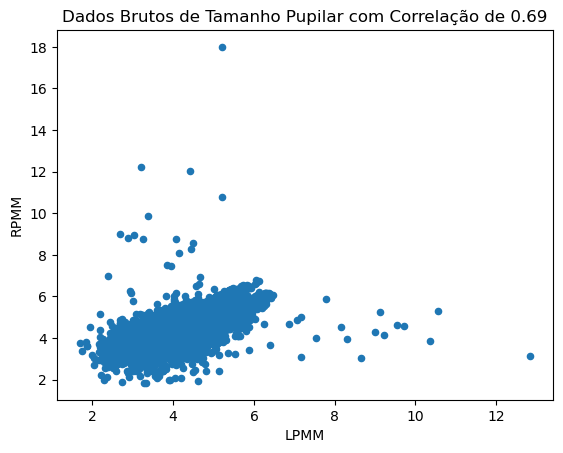

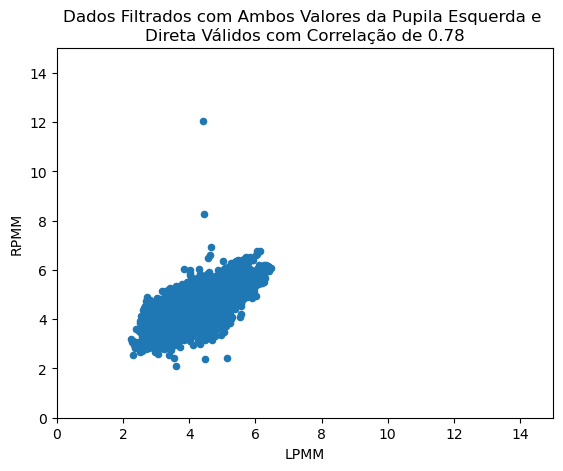

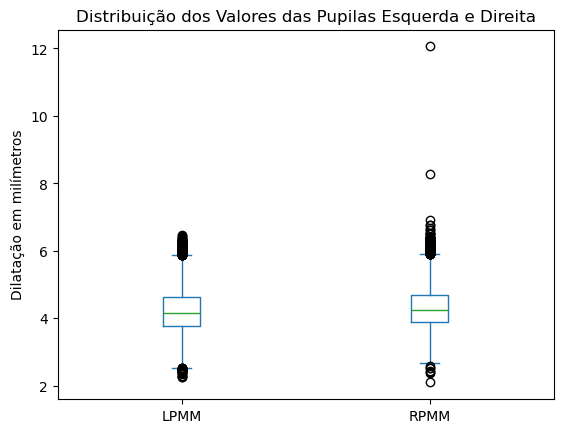

In [31]:
# TRATAMENTO DO TAMANHO PUPILAR
# dataframe de tamanho pupilar
df_pupil = df_analise_roi[['participant_id', 'block_id', 'MEDIA_NAME', 
                        'TIME', 'LPMM', 'RPMM', 'LPMMV', 'RPMMV']]
num_pupil_logs = len(df_pupil)

corr = df_pupil['LPMM'].corr(df_pupil['RPMM'])

# plot de dados brutos
df_pupil.plot(
    kind='scatter', 
    x='LPMM', 
    y='RPMM', 
    title=f'Dados Brutos de Tamanho Pupilar com Correlação de {corr:.2f}')

# novo cálculo de correlação
mask = ((df_pupil['LPMMV']==1) & (df_pupil['RPMMV']==1))
corr = df_pupil[mask]['LPMM'].corr(df_pupil[mask]['RPMM'])

# plot de dados filtrados com ambos LEFT e RIGHT em 1
df_pupil[mask].plot(
    kind='scatter',
    x='LPMM',
    y='RPMM',
    title=f'Dados Filtrados com Ambos Valores da Pupila Esquerda e \nDireta Válidos com Correlação de {corr:.2f}',
    xlim=(0, 15),
    ylim=(0,15),
)

# distribuição dos registros de tamanho de pupila
df_pupil[mask].plot(
    kind='box',
    y=['LPMM', 'RPMM'],
    title='Distribuição dos Valores das Pupilas Esquerda e Direita',
    ylabel='Dilatação em milímetros'
)

Tratando dados de medida pupilar.

É necessário mostrar por que é uma boa ideia calcular a média entre a pupila esquerda e direita.

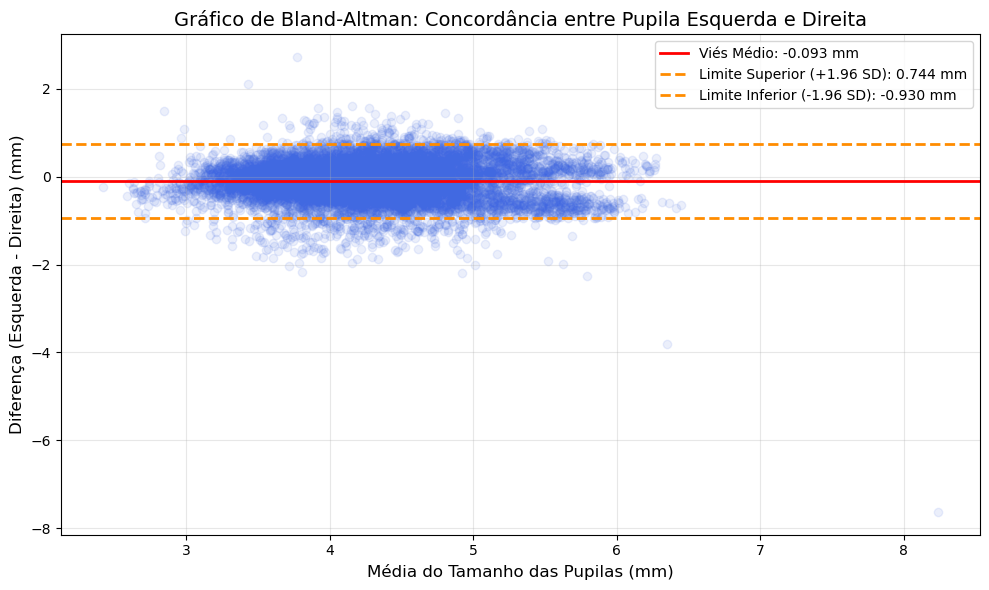

In [ ]:
# Cria uma cópia apenas com os dados válidos para não alterar o df original
df_valid = df_pupil[mask].copy()

# 1. O Eixo X do Bland-Altman é a MÉDIA das duas medições
df_valid['mean_pupil'] = (df_valid['LPMM'] + df_valid['RPMM']) / 2

# 2. O Eixo Y do Bland-Altman é a DIFERENÇA entre as duas medições
df_valid['diff_pupil'] = df_valid['LPMM'] - df_valid['RPMM']

# 3. Cálculo das estatísticas de concordância
mean_diff = df_valid['diff_pupil'].mean() # Viés (Bias)
std_diff = df_valid['diff_pupil'].std()   # Desvio padrão da diferença

# Limites de Concordância (95% dos dados devem cair aqui dentro se a distribuição for normal)
upper_limit = mean_diff + 1.96 * std_diff
lower_limit = mean_diff - 1.96 * std_diff

# 4. Construção do Gráfico
plt.figure(figsize=(10, 6))

# Plota os pontos (usando alpha para lidar com a sobreposição de milhares de linhas)
plt.scatter(df_valid['mean_pupil'], df_valid['diff_pupil'], alpha=0.1, color='royalblue')

# Adiciona a linha de viés médio (deve estar bem próxima de 0)
plt.axhline(mean_diff, color='red', linestyle='-', linewidth=2, 
            label=f'Viés Médio: {mean_diff:.3f} mm')

# Adiciona as linhas dos limites de concordância superior e inferior
plt.axhline(upper_limit, color='darkorange', linestyle='--', linewidth=2, 
            label=f'Limite Superior (+1.96 SD): {upper_limit:.3f} mm')
plt.axhline(lower_limit, color='darkorange', linestyle='--', linewidth=2, 
            label=f'Limite Inferior (-1.96 SD): {lower_limit:.3f} mm')

# Formatação visual
plt.title('Gráfico de Bland-Altman: Concordância entre Pupila Esquerda e Direita', fontsize=14)
plt.xlabel('Média do Tamanho das Pupilas (mm)', fontsize=12)
plt.ylabel('Diferença (Esquerda - Direita) (mm)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Exibe o gráfico
plt.show()

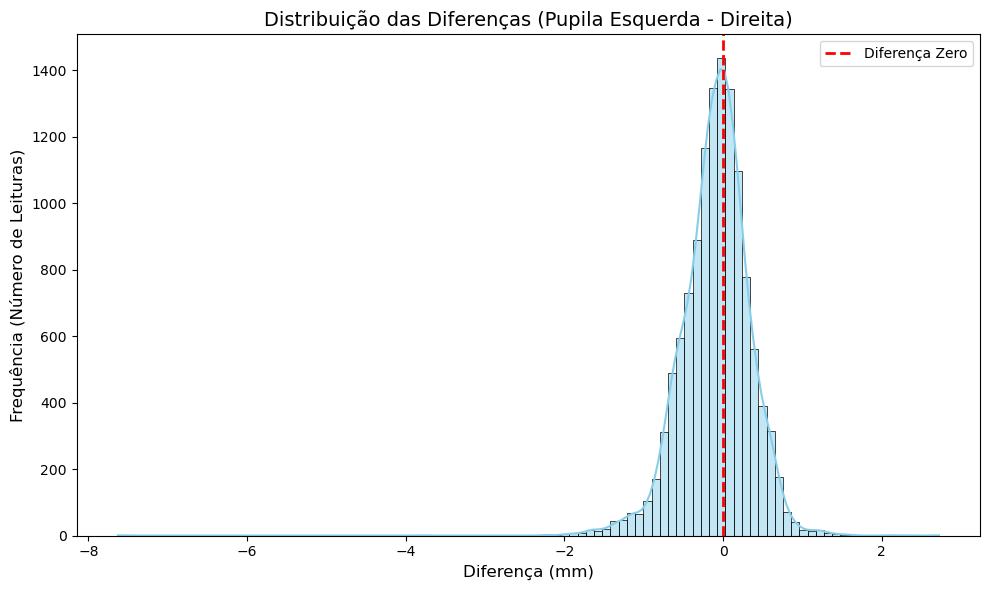

--- Resultado do Teste de Normalidade D'Agostino-Pearson ---
Estatística do Teste: 3212.6196
Valor-p: 0.0000e+00

Conclusão Estatística:
A amostra não segue perfeitamente uma distribuição normal (rejeitamos a hipótese nula).
-> ATENÇÃO: Veja as notas de interpretação abaixo.


In [ ]:
# Usando a coluna 'diff_pupil' que já criamos no passo anterior
diferencas = df_valid['diff_pupil']

# 1. Inspeção Visual: Histograma com curva de densidade
plt.figure(figsize=(10, 6))
sns.histplot(diferencas, bins=100, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribuição das Diferenças (Pupila Esquerda - Direita)', fontsize=14)
plt.xlabel('Diferença (mm)', fontsize=12)
plt.ylabel('Frequência (Número de Leituras)', fontsize=12)

# Adiciona uma linha pontilhada no zero para referência
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Diferença Zero')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Teste Estatístico Formal: D'Agostino-Pearson
# Este teste avalia a assimetria (skewness) e a curtose (kurtosis) da distribuição
stat, p_valor = stats.normaltest(diferencas)

print(f"--- Resultado do Teste de Normalidade D'Agostino-Pearson ---")
print(f"Estatística do Teste: {stat:.4f}")
print(f"Valor-p: {p_valor:.4e}")

# 3. Interpretação do Teste
alpha = 0.05 # Nível de significância padrão
if p_valor > alpha:
    print("\nConclusão Estatística:")
    print("A amostra parece seguir uma distribuição normal (não podemos rejeitar a hipótese nula).")
    print("-> SUCESSO: A pré-suposição do Bland-Altman está plenamente atendida.")
else:
    print("\nConclusão Estatística:")
    print("A amostra não segue perfeitamente uma distribuição normal (rejeitamos a hipótese nula).")
    print("-> ATENÇÃO: Veja as notas de interpretação abaixo.")

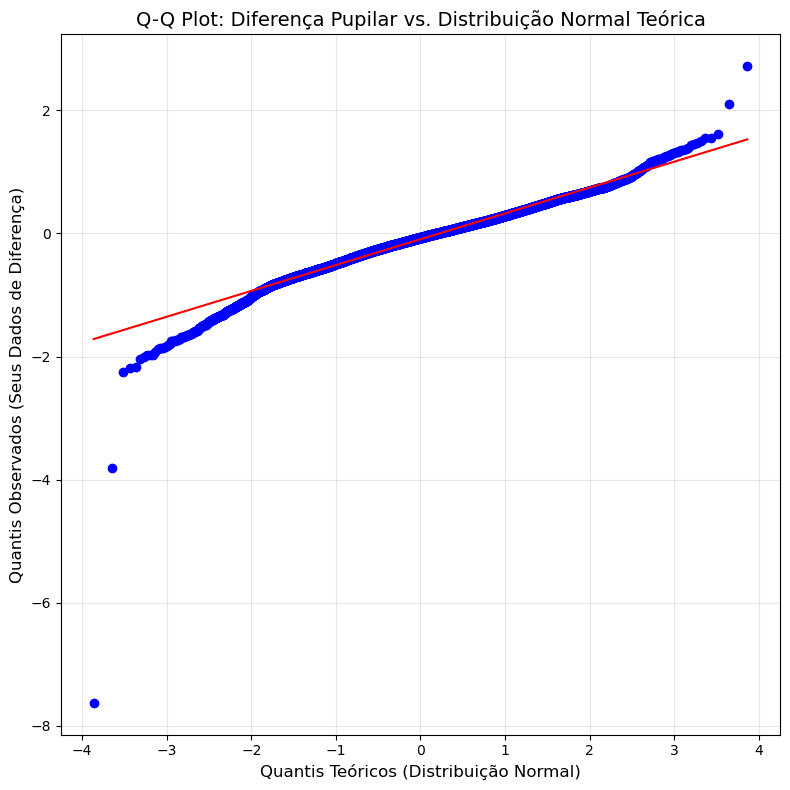

In [ ]:
# Usa a mesma variável de diferenças que criamos antes
diferencas = df_valid['diff_pupil']

# Configuração do gráfico
plt.figure(figsize=(8, 8))

# O probplot gera o Q-Q plot. 
# dist="norm" compara com a distribuição normal teórica
stats.probplot(diferencas, dist="norm", plot=plt)

# Formatação visual para manter o padrão do seu TCC
plt.title('Q-Q Plot: Diferença Pupilar vs. Distribuição Normal Teórica', fontsize=14)
plt.xlabel('Quantis Teóricos (Distribuição Normal)', fontsize=12)
plt.ylabel('Quantis Observados (Seus Dados de Diferença)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()